In [ ]:
#RUNNARE SOLO LA PRIMA VOLTA POI NON PIU
import nltk
import ssl

# --- FIX PER IL PROBLEMA SSL SU MAC ---
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# --- SCARICAMENTO MANUALE DEI DATI PER TEXTBLOB ---
print("Inizio download...")
nltk.download('brown')
nltk.download('punkt')
nltk.download('punkt_tab')  # Spesso richiesto dalle nuove versioni
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('conll2000')
nltk.download('movie_reviews')
print("Download completato!")

Inizio download...


[nltk_data] Downloading package brown to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   U

Download completato!


Recensioni Negative originali: 348
Recensioni Positive originali: 18799

Nuovo Dataset Bilanciato: 696 righe totali
sentiment
negative    348
positive    348
Name: count, dtype: int64
Dataset bilanciato salvato come 'LLM_DF_Balanced.csv'


/var/folders/s3/5xdhgys539jg6hfd91tbj95w0000gn/T/ipykernel_87171/901602042.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tb_category', data=df, palette='pastel', order=['Neutral', 'Positive', 'Negative'])


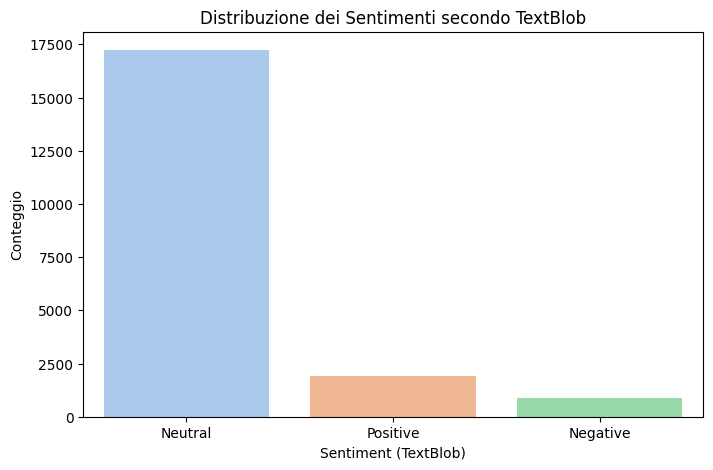

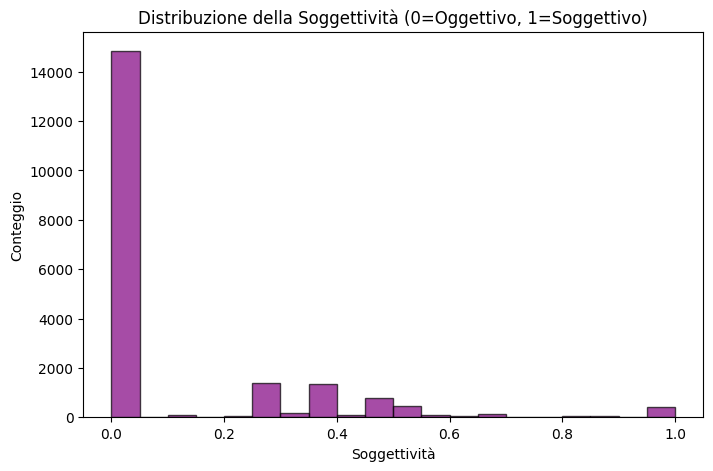

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob

# 1. CARICAMENTO E PULIZIA
df = pd.read_csv('LLM_DF.csv')

# Mappatura: Stelle -> Sentiment
def map_sentiment(star):
    if star >= 4:
        return 'positive'
    elif star <= 2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['stars'].apply(map_sentiment)

#Bilanciamo il dataset separando le classi in positive e negative
df_pos = df[df['sentiment'] == 'positive']
df_neg = df[df['sentiment'] == 'negative']

# Contiamo quante sono le negative
min_count = len(df_neg)
print(f"Recensioni Negative originali: {min_count}")
print(f"Recensioni Positive originali: {len(df_pos)}")

# Prendiamo un campione casuale di positive uguale al numero di negative
df_pos_undersampled = df_pos.sample(n=min_count, random_state=42)

# Uniamo tutto (Questo è il dataset che useremo per il Machine Learning)
df_balanced = pd.concat([df_pos_undersampled, df_neg])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # Mischiamo le righe

print(f"\nNuovo Dataset Bilanciato: {len(df_balanced)} righe totali")
print(df_balanced['sentiment'].value_counts())

# Salviamo il dataset bilanciato per lo step successivo (FastText)
df_balanced.to_csv('LLM_DF_Balanced.csv', index=False)
print("Dataset bilanciato salvato come 'LLM_DF_Balanced.csv'")

#Qui facciamo l'analisi con textblob
def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    # Polarity: da -1 (negativo) a +1 (positivo)
    # Subjectivity: da 0 (oggettivo) a 1 (soggettivo)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Applichiamo TextBlob al dataset ORIGINALE (per vedere la distribuzione reale)
# (Usiamo una lambda function per applicare la funzione a ogni riga)
df[['tb_polarity', 'tb_subjectivity']] = df['comment'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

# Definiamo le categorie di TextBlob (per Figura 11)
def categorize_polarity(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

df['tb_category'] = df['tb_polarity'].apply(categorize_polarity)

# GRAFICO 1: Distribuzione Sentiment TextBlob (Replica Figura 11)
plt.figure(figsize=(8, 5))
sns.countplot(x='tb_category', data=df, palette='pastel', order=['Neutral', 'Positive', 'Negative'])
plt.title('Distribuzione dei Sentimenti secondo TextBlob')
plt.xlabel('Sentiment (TextBlob)')
plt.ylabel('Conteggio')
plt.savefig('textblob_sentiment_dist.png')
plt.show()

# GRAFICO 2: Distribuzione Soggettività (Replica Figura 12)
plt.figure(figsize=(8, 5))
plt.hist(df['tb_subjectivity'], bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribuzione della Soggettività (0=Oggettivo, 1=Soggettivo)')
plt.xlabel('Soggettività')
plt.ylabel('Conteggio')
plt.savefig('textblob_subjectivity_dist.png')
plt.show()



/var/folders/s3/5xdhgys539jg6hfd91tbj95w0000gn/T/ipykernel_87171/3970401713.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, order=['positive', 'neutral', 'negative'], palette='viridis')


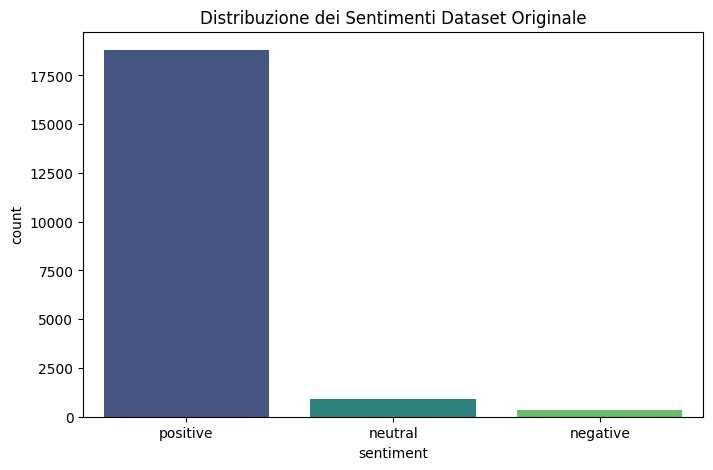

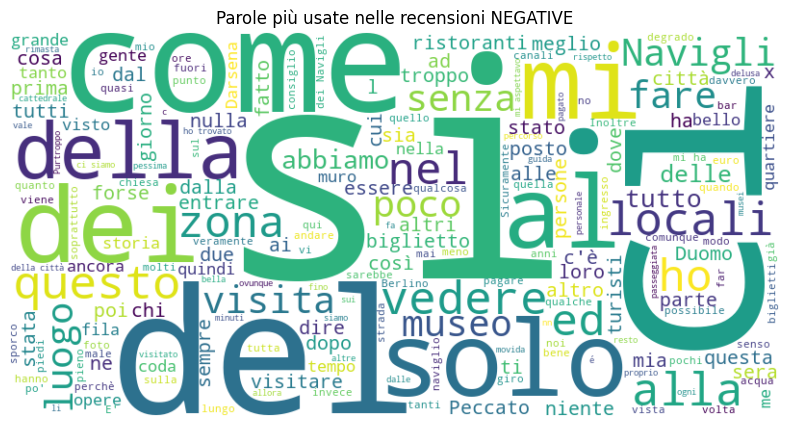

In [5]:
#DATASET ORIGINALE SENZA BILANCIAMENTO

# Pulizia veloce del testo (rimuove valori nulli se ce ne sono)
df = df.dropna(subset=['comment'])

# 2. GRAFICO DISTRIBUZIONE (Figura 1)
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, order=['positive', 'neutral', 'negative'], palette='viridis')
plt.title('Distribuzione dei Sentimenti Dataset Originale')
plt.savefig('distribuzione_sentiment.png')
plt.show()

# 3. WORDCLOUD (Figura 6, 7, 8...)
# Stopwords italiane base (parole da ignorare)
stopwords = set(['di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una', 'e', 'o', 'ma', 'se', 'perché', 'anche', 'che', 'non', 'è', 'sono', 'era', 'erano', 'molto', 'più', 'milano'])

def genera_wordcloud(testo_series, titolo):
    testo = " ".join(review for review in testo_series.astype(str))
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(testo)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(titolo)
    plt.show()

# Genera per Negative
genera_wordcloud(df[df['sentiment']=='negative']['comment'], 'Parole più usate nelle recensioni NEGATIVE')